# Modelización Matemática - Parcial 2
## Diego Ángel Gallardo Costilla

In [1]:
def triangular(x,a,m,b):
    if x < a or x > b:
        return 0
    if a <= x <= m:
        return (x - a) / (m - a)
    if m < x <= b:
        return (b - x) / (b - m)
    
def trapezoidal(x,a,b,c,d):
    if x <= a or x >= d: 
        return 0
    if b <= x <= c: 
        return 1
    if a < x < b: 
        return (x - a) / (b - a)
    if c < x < d: 
        return (d - x) / (d - c)

In [3]:
# Primero, hemos de importar las siguientes librerías:
import numpy as np
import matplotlib.pyplot as plt

Fuzzificación: Temp(22.5) -> [('B', 0.75), ('A', 0.25)]
Fuzzificación: Hum(40) -> [('B', 1)]

Resultado final (Centroide): 0.00


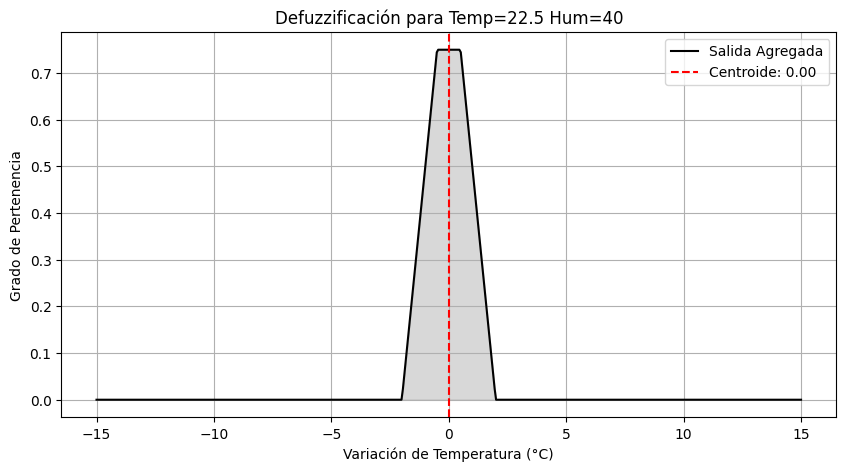

In [ ]:
# 1. FUNCIONES DE PERTENENCIA
# Ya las teníamos definidas en el primer ejercicio, son la triangular y la trapezoidal.

# 2. DEFINICIÓN DE VARIABLES Y ETIQUETAS
temp_labels = {
    'B':  lambda x: trapezoidal(x, 0, 0, 20, 30),
    'A':  lambda x: trapezoidal(x, 20, 30, 40, 45),
}

hum_labels = {
    'B': lambda x: trapezoidal(x, 0, 0, 40, 70),
    'A': lambda x: trapezoidal(x, 40, 70, 100, 100)
}

output_labels = {
    'B': lambda x: trapezoidal(x, -5, -5, -2, 0),
    'M':  lambda x: triangular(x, -2, 0, 2),       
    'S': lambda x: trapezoidal(x, 0, 2, 5, 5)    
}


# 3. MOTOR DE INFERENCIA
def solve_fuzzy_system(temp_val, hum_val):
    # Fuzzificación (Grados de verdad)
    mu_temp = {k: f(temp_val) for k, f in temp_labels.items()}
    mu_hum = {k: f(hum_val) for k, f in hum_labels.items()}
    
    print(f"Fuzzificación: Temp({temp_val}) -> {[(k,v) for k,v in mu_temp.items() if v>0]}")
    print(f"Fuzzificación: Hum({hum_val}) -> {[(k,v) for k,v in mu_hum.items() if v>0]}")

    # Aplicación de Reglas (Mamdani)
    # Regla 1: IF B AND A THEN SP
    r1 = min(mu_temp['B'], mu_hum['B'])
    # Regla 2: IF B AND MA THEN SN
    r2 = min(mu_temp['B'], mu_hum['A'])
    # Regla 3: IF N AND A THEN M
    r3 = min(mu_temp['A'], mu_hum['A'])
    # Regla 4: IF N AND MA THEN BP
    r4 = min(mu_temp['A'], mu_hum['B'])

    # Agregación (Máximo)
    x_range = np.linspace(-15, 15, 500)
    aggregate_membership = []
    
    for x in x_range:
        # Mamdani: min entre el disparo de la regla y la función de salida
        m1 = min(r1, output_labels['M'](x))
        m2 = min(r2, output_labels['S'](x))
        m3 = min(r3, output_labels['B'](x))
        m4 = min(r4, output_labels['M'](x))
        aggregate_membership.append(max(m1, m2, m3, m4))

    # Defuzzificación (Centroide)
    num = np.sum(np.array(aggregate_membership) * x_range)
    den = np.sum(aggregate_membership)
    centroid = num / den if den != 0 else 0
    
    return x_range, aggregate_membership, centroid

# 4. EJECUCIÓN Y VISUALIZACIÓN
t_in, h_in = 22.5, 40
x_out, y_out, result = solve_fuzzy_system(t_in, h_in)

print(f"\nResultado final (Centroide): {result:.2f}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(x_out, y_out, 'k-', label='Salida Agregada')
plt.fill_between(x_out, y_out, color='gray', alpha=0.3)
plt.axvline(result, color='r', linestyle='--', label=f'Centroide: {result:.2f}')
plt.title(f"Defuzzificación para Temp={t_in} Hum={h_in}")
plt.xlabel("Variación de Temperatura (°C)")
plt.ylabel("Grado de Pertenencia")
plt.legend()
plt.grid(True)
plt.show()

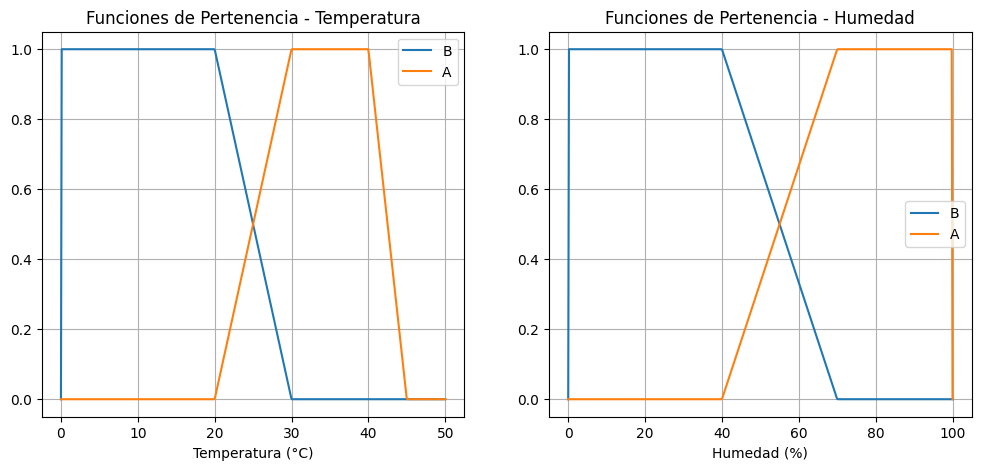

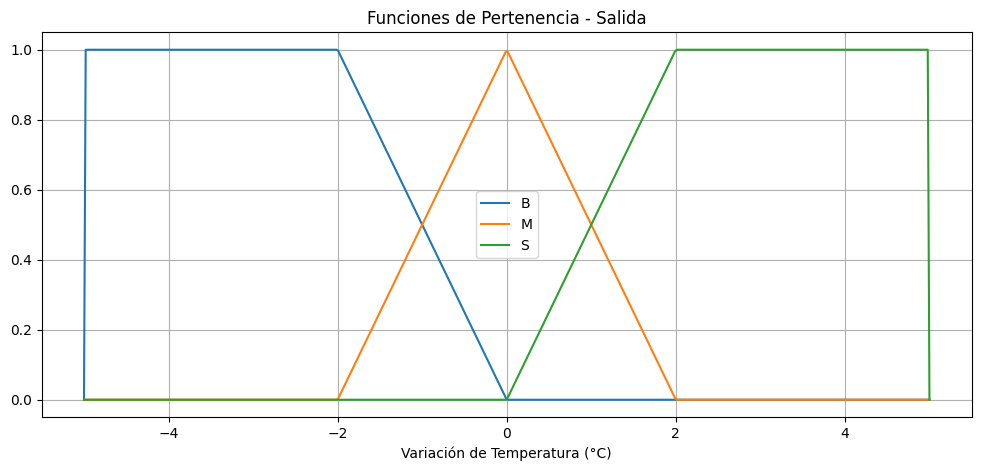

In [10]:
# Representamos también las funciones de pertenencia para visualizar mejor el sistema:
x_temp = np.linspace(0, 50, 500)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for label, func in temp_labels.items():
    plt.plot(x_temp, [func(x) for x in x_temp], label=label)
plt.title("Funciones de Pertenencia - Temperatura")
plt.xlabel("Temperatura (°C)")
plt.legend()
plt.grid(True)
# Representamos las funciones de pertenencia para la humedad
x_hum = np.linspace(0, 100, 500)
plt.subplot(1, 2, 2)
for label, func in hum_labels.items():
    plt.plot(x_hum, [func(x) for x in x_hum], label=label)
plt.title("Funciones de Pertenencia - Humedad")
plt.xlabel("Humedad (%)")
plt.legend()
plt.grid(True)
# Ahora las de salida
x_out = np.linspace(-5, 5, 500)
plt.figure(figsize=(12, 5))
for label, func in output_labels.items():
    plt.plot(x_out, [func(x) for x in x_out], label=label)
plt.title("Funciones de Pertenencia - Salida")
plt.xlabel("Variación de Temperatura (°C)")
plt.legend()
plt.grid(True)

In [6]:
def tg(x,y):
    return min(x, y)
def tp(x,y):
    return x*y
def tl(x,y):
    return max(0,x+y-1)

In [7]:
def sg(x,y):
    return max(x,y)
def sp(x,y):
    return x+y-x*y
def sl(x,y):
    return min(1,x+y)

In [8]:
def imp_godel(y, z):
    return 1 if y <= z else z
def imp_producto(y, z):
    return 1 if y <= z else z / y
def imp_lukasiewicz(y, z):
    return min(1, 1 - y + z)

Para la pregunta 3

Fuzzificación: Temp(22.5) -> [('B', 0.75), ('A', 0.25)]
Fuzzificación: Hum(40) -> [('B', 1)]

Resultado final (Centroide): 0.00


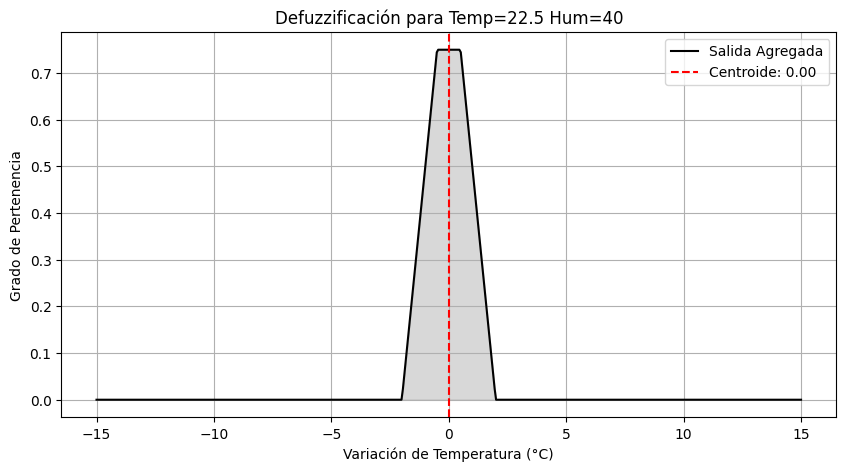

In [ ]:
temp_labels = {
    'B':  lambda x: trapezoidal(x, 0, 0, 20, 30),
    'A':  lambda x: trapezoidal(x, 20, 30, 40, 45),
}

hum_labels = {
    'B': lambda x: trapezoidal(x, 0, 0, 40, 70),
    'A': lambda x: trapezoidal(x, 40, 70, 100, 100)
}

output_labels = {
    'B': lambda x: trapezoidal(x, -5, -5, -2, 0),
    'M':  lambda x: triangular(x, -2, 0, 2),       
    'S': lambda x: trapezoidal(x, 0, 2, 5, 5)    
}

# 3. MOTOR DE INFERENCIA
def solve_fuzzy_system(temp_val, hum_val):
    # Fuzzificación (Grados de verdad)
    mu_temp = {k: f(temp_val) for k, f in temp_labels.items()}
    mu_hum = {k: f(hum_val) for k, f in hum_labels.items()}
    
    print(f"Fuzzificación: Temp({temp_val}) -> {[(k,v) for k,v in mu_temp.items() if v>0]}")
    print(f"Fuzzificación: Hum({hum_val}) -> {[(k,v) for k,v in mu_hum.items() if v>0]}")

    # Procedemos a cambiar los conjuntores de Godel por los de producto para ver la diferencia en el resultado final
    # Regla 1: IF B AND A THEN SP
    r1 = tp(mu_temp['B'], mu_hum['B'])
    # Regla 2: IF B AND MA THEN SN
    r2 = tp(mu_temp['B'], mu_hum['A'])
    # Regla 3: IF N AND A THEN M
    r3 = tp(mu_temp['A'], mu_hum['A'])
    # Regla 4: IF N AND MA THEN BP
    r4 = tp(mu_temp['A'], mu_hum['B'])

    # Agregación (Máximo)
    x_range = np.linspace(-15, 15, 500)
    aggregate_membership = []
    
    for x in x_range:
        # Mamdani: min entre el disparo de la regla y la función de salida
        m1 = min(r1, output_labels['M'](x))
        m2 = min(r2, output_labels['S'](x))
        m3 = min(r3, output_labels['B'](x))
        m4 = min(r4, output_labels['M'](x))
        aggregate_membership.append(max(m1, m2, m3, m4))

    # Defuzzificación (Centroide)
    num = np.sum(np.array(aggregate_membership) * x_range)
    den = np.sum(aggregate_membership)
    centroid = num / den if den != 0 else 0
    
    return x_range, aggregate_membership, centroid

# 4. EJECUCIÓN Y VISUALIZACIÓN
t_in, h_in = 22.5, 40
x_out, y_out, result = solve_fuzzy_system(t_in, h_in)

print(f"\nResultado final (Centroide): {result:.2f}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(x_out, y_out, 'k-', label='Salida Agregada')
plt.fill_between(x_out, y_out, color='gray', alpha=0.3)
plt.axvline(result, color='r', linestyle='--', label=f'Centroide: {result:.2f}')
plt.title(f"Defuzzificación para Temp={t_in} Hum={h_in}")
plt.xlabel("Variación de Temperatura (°C)")
plt.ylabel("Grado de Pertenencia")
plt.legend()
plt.grid(True)
plt.show()

No hay diferencia entre usar la t-norma de Godel (mínimo) o la t-norma producto para la aplicación de las reglas.